# Exercice 1 : Créer un réseau de neurones convolutionnel simple (CNN)

## 1. Importation des bibliothèques nécessaires

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Chargement du jeu de données (Fashion MNIST)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme de l'ensemble d'entraînement : x_train=(60000, 28, 28), y_train=(60000,)
Forme de l'ensemble de test : x_test=(10000, 28, 28), y_test=(10000,)


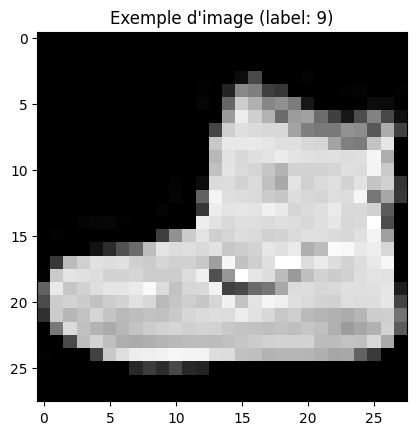

In [13]:
# Chargez le jeu de données Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Forme de l'ensemble d'entraînement : x_train={x_train.shape}, y_train={y_train.shape}")
print(f"Forme de l'ensemble de test : x_test={x_test.shape}, y_test={y_test.shape}")

# Affichez un exemple d'image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Exemple d'image (label: {y_train[0]})")
plt.show()

## 3. Prétraitement des données
### Redimensionnement des fonctionnalités et normalisation

In [14]:
# Normaliser les pixels à une plage de [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Redimensionner les images pour ajouter la dimension du canal (gris = 1 canal)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"Forme de x_train après redimensionnement : {x_train.shape}")
print(f"Forme de x_test après redimensionnement : {x_test.shape}")

Forme de x_train après redimensionnement : (60000, 28, 28, 1)
Forme de x_test après redimensionnement : (10000, 28, 28, 1)


### Encodage des étiquettes (One-Hot Encoding)

In [15]:
# Convertir les étiquettes en encodage one-hot
num_classes = 10 # Fashion MNIST a 10 classes
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Forme de y_train après encodage one-hot : {y_train.shape}")
print(f"Forme de y_test après encodage one-hot : {y_test.shape}")

Forme de y_train après encodage one-hot : (60000, 10)
Forme de y_test après encodage one-hot : (10000, 10)


## 4. Création du modèle de réseau de neurones convolutionnel (CNN)

In [16]:
input_shape = x_train.shape[1:] # (28, 28, 1)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compilation et entraînement du modèle

In [17]:
batch_size = 128
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accuracy: 0.7481 - loss: 0.6949 - val_accuracy: 0.8370 - val_loss: 0.4515
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.8338 - loss: 0.4602 - val_accuracy: 0.8600 - val_loss: 0.3871
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.8534 - loss: 0.4093 - val_accuracy: 0.8748 - val_loss: 0.3561
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.8655 - loss: 0.3754 - val_accuracy: 0.8800 - val_loss: 0.3336
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.8735 - loss: 0.3545 - val_accuracy: 0.8755 - val_loss: 0.3355
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.8775 - loss: 0.3412 - val_accuracy: 0.8908 - val_loss: 0.3056
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.8837 - loss: 0.3257 - val_accuracy: 0.8957 - val_loss: 0.2926
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.8863 - loss: 0

## 6. Évaluation de la perte et de la précision du modèle

Perte sur l'ensemble de test : 0.2988
Précision sur l'ensemble de test : 0.8930


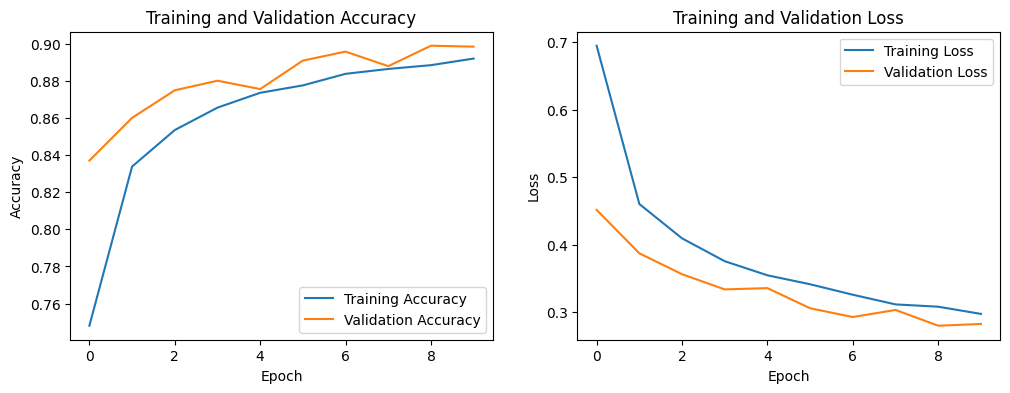

In [18]:
score = model.evaluate(x_test, y_test, verbose=0)
print(f"Perte sur l'ensemble de test : {score[0]:.4f}")
print(f"Précision sur l'ensemble de test : {score[1]:.4f}")

# Visualiser l'historique d'entraînement
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()